In [27]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('week1/insurance.csv')
 
print(df.head())
print(df.shape)

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520
(1338, 7)


In [28]:
print(df.isnull().sum())
print(df.describe())

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64
               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.000000    34.693750     2.000000  16639.912515
max      64.000000    53.130000     5.000000  63770.428010


In [29]:
# BMI Category

df['bmi_category'] = pd.cut(df['bmi'], 
    bins = [0, 18.5, 24.9,29.9,100],
    labels = ['Underweight', 'Normal', 'Overweight', 'Obese'])

print(df['bmi_category'].value_counts(normalize=True). round(1) * 100)

bmi_category
Obese          50.0
Overweight     30.0
Normal         20.0
Underweight     0.0
Name: proportion, dtype: float64


In [30]:
# Risk tier based on BMI and smoker status 

def assign_risk_tier(row):
    if row['smoker'] == 'yes' and row['bmi_category'] == 'Obese':
        return 'Very High'
    elif row['smoker'] == 'yes':
        return 'High'
    elif row['bmi_category'] == 'Obese':
        return 'Medium'
    else:
        return 'Low'

df['risk_tier'] = df.apply(assign_risk_tier, axis=1)

print(df['risk_tier'].value_counts())
print()
print(df.groupby('risk_tier')['charges'].mean().round(2).sort_values(ascending=False))

risk_tier
Medium       569
Low          495
Very High    147
High         127
Name: count, dtype: int64

risk_tier
Very High    41355.87
High         21279.14
Medium        8809.55
Low           8002.89
Name: charges, dtype: float64


In [31]:
# average charges by region and risk tier 

regional_charge = df.groupby(['region', 'risk_tier'])[
    'charges'].mean().round(2).unstack()

print(regional_charge) 

risk_tier      High      Low    Medium  Very High
region                                           
northeast  20775.26  8276.99  10280.10   40648.08
northwest  22152.99  8076.00   9086.10   42425.28
southeast  21534.42  7901.64   8089.26   42064.29
southwest  20404.78  7684.83   8331.93   40065.59


risk tier is the primary pricing driver, region is a secondary modifier.

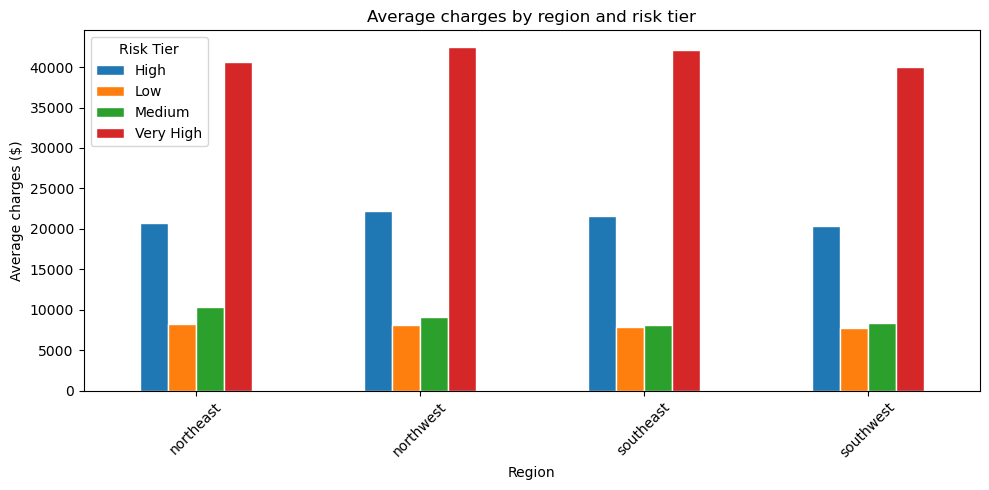

In [32]:
regional_charge.plot(
    kind='bar',
    figsize=(10, 5),
    edgecolor= 'white')

plt.title('Average charges by region and risk tier')
plt.xlabel('Region')
plt.ylabel('Average charges ($)')
plt.xticks(rotation=45)
plt.legend(title='Risk Tier')
plt.tight_layout()
plt.show()



In [38]:
# Age vs pricing within risk categories

df['age_categories'] = pd.cut(df['age'],
    bins=[16, 25, 40, 65],
    labels=['Young (16-25)', 'Adult (26-40)', 'Middle Age (41-65)'])

age_charge = df.groupby(['age_categories', 'risk_tier'], observed=True)[
    'charges'].mean().round(2).unstack()

print(age_charge)
                     

risk_tier               High       Low    Medium  Very High
age_categories                                             
Young (16-25)       17606.09   3939.02   4070.46   36252.91
Adult (26-40)       18966.63   6201.19   6267.85   39734.66
Middle Age (41-65)  25023.80  11735.91  11941.32   44929.81


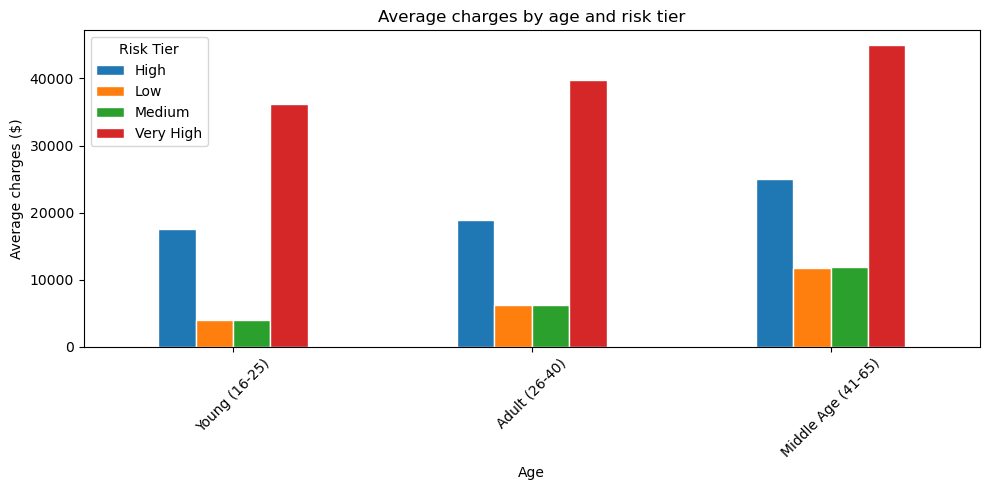

In [40]:
age_charge.plot(
    kind ='bar',
    figsize =(10,5),
    edgecolor='white')

plt.title('Average charges by age and risk tier')
plt.xlabel('Age')
plt.ylabel('Average charges ($)')
plt.xticks(rotation=45)
plt.legend(title='Risk Tier')
plt.tight_layout()
plt.show()


Age has a much stronger proportional impact on low risk customers than high risk ones. For Very High risk customers, the smoking and obesity premium already dominates so much that age adds relatively little. But for a healthy non-smoker, age alone nearly triples their premium. Age is a primary pricing driver for low-risk segments but a secondary driver for high-risk segments where behavioral factors dominate.

In [41]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np

In [42]:
# Encode categorical variables
df_model = df.copy()

le = LabelEncoder()
df_model['sex_encoded'] = le.fit_transform(df_model['sex'])
df_model['smoker_encoded'] = le.fit_transform(df_model['smoker'])
df_model['region_encoded'] = le.fit_transform(df_model['region'])
df_model['bmi_category_encoded'] = le.fit_transform(df_model['bmi_category'])
df_model['risk_tier_encoded'] = le.fit_transform(df_model['risk_tier'])

# Define features and target
X = df_model[['age', 'bmi', 'children', 'sex_encoded', 
              'smoker_encoded', 'region_encoded', 
              'bmi_category_encoded', 'risk_tier_encoded']]
y = df_model['charges']

print(X.shape)
print(y.shape)

(1338, 8)
(1338,)


In [43]:
# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f"Training set: {X_train.shape[0]} rows")
print(f"Test set: {X_test.shape[0]} rows")

# Train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"\nR² Score: {round(r2, 3)}")
print(f"Mean Absolute Error: ${round(mae, 2)}")

Training set: 1070 rows
Test set: 268 rows

R² Score: 0.84
Mean Absolute Error: $3190.99


In [44]:
# Feature importance
feature_names = X.columns
coefficients = model.coef_

importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
}).sort_values('Coefficient', ascending=False)

print(importance)

                Feature   Coefficient
4        smoker_encoded  23258.169460
7     risk_tier_encoded   6233.479057
6  bmi_category_encoded    922.575247
2              children    417.536075
0                   age    257.521010
1                   bmi   -255.850924
3           sex_encoded   -265.544590
5        region_encoded   -347.651293


Linear regression model achieves R²=0.84, explaining 84% of charge variation. Smoker status is the dominant predictor with a coefficient of 23,258 — nearly 4x stronger than risk tier ($6,233). Age, BMI category, and region are weak secondary predictors. This confirms that behavioral factors (smoking) outweigh demographic and geographic factors in insurance pricing.